In [1]:
# ============================================================
# Week 10 — Fisher Transform, Inverse Fisher, COG
# Validation: EUR/USD D1, 2015-2024 (2596 bars)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import signal as scipy_signal

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Load data
df = pd.read_csv('C:/zorro/Data/Fisher_IFT_COG_EURUSD_D1.csv')

# Synthetic date index — 2596 trading days from Jan 2015
dates = pd.bdate_range(start='2015-01-02', periods=len(df))
df.index = dates

print(f"Loaded: {len(df)} bars")
print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}")
print(f"Close range: {df['close'].min():.5f} → {df['close'].max():.5f}")
print(df.describe().round(4))

Loaded: 2596 bars
Date range: 2015-01-02 → 2024-12-13
Close range: 0.96192 → 1.25131
            bar      close   midprice     fisher  fisher_trig  elegant_osc  \
count  2596.000  2596.0000  2596.0000  2596.0000    2596.0000    2596.0000   
mean   1298.500     1.1188     1.1189    -0.1316      -0.1321      -0.0153   
std     749.545     0.0522     0.0522     1.8425       1.8432       0.2766   
min       1.000     0.9619     0.9592    -7.2278      -7.2278      -0.8233   
25%     649.750     1.0843     1.0845    -1.4138      -1.4138      -0.2073   
50%    1298.500     1.1144     1.1146    -0.0751      -0.0751      -0.0095   
75%    1947.250     1.1568     1.1565     1.1697       1.1697       0.1791   
max    2596.000     1.2513     1.2493     7.4104       7.4104       0.7033   

             cog   cog_trig  
count  2596.0000  2596.0000  
mean     -5.5005    -5.5005  
std       0.0137     0.0137  
min      -5.5611    -5.5611  
25%      -5.5086    -5.5086  
50%      -5.5003    -5.5003  
75

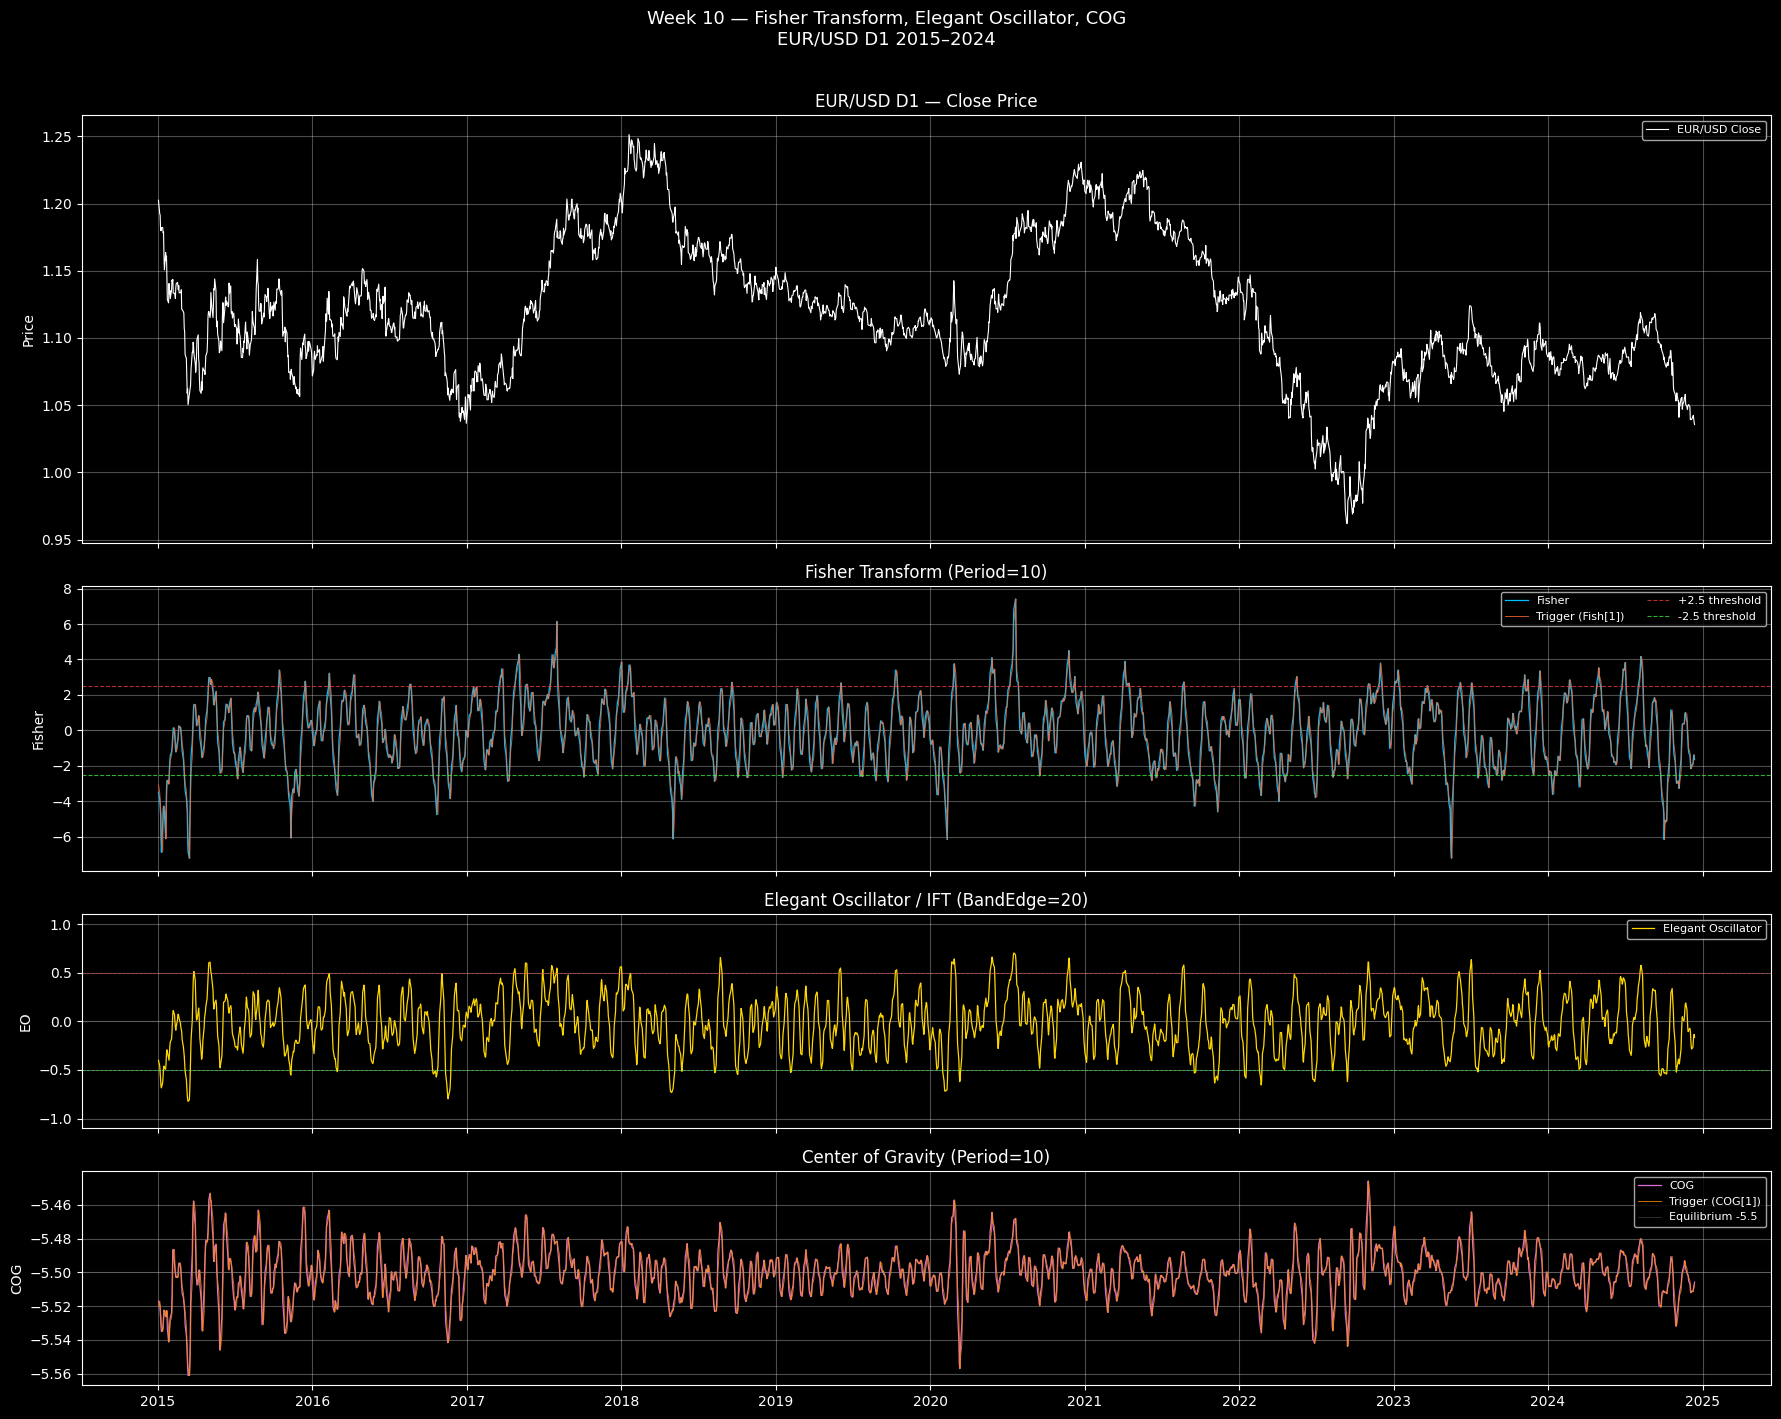

Saved: Week10_Overview.png


In [2]:
# ============================================================
# Cell 2 — Multi-panel overview: Price + all three indicators
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2, 1.5, 1.5]})
fig.suptitle('Week 10 — Fisher Transform, Elegant Oscillator, COG\nEUR/USD D1 2015–2024', 
             fontsize=13, y=1.01)

# --- Panel 1: Price ---
ax1 = axes[0]
ax1.plot(df.index, df['close'], color='white', linewidth=0.8, label='EUR/USD Close')
ax1.set_ylabel('Price')
ax1.set_title('EUR/USD D1 — Close Price')
ax1.legend(loc='upper right', fontsize=8)

# --- Panel 2: Fisher Transform ---
ax2 = axes[1]
ax2.plot(df.index, df['fisher'],      color='#00BFFF', linewidth=0.9, label='Fisher')
ax2.plot(df.index, df['fisher_trig'], color='#FF6B35', linewidth=0.7, 
         alpha=0.8, label='Trigger (Fish[1])')
ax2.axhline( 2.5, color='#FF4444', linewidth=0.8, linestyle='--', alpha=0.7, label='+2.5 threshold')
ax2.axhline(-2.5, color='#44FF44', linewidth=0.8, linestyle='--', alpha=0.7, label='-2.5 threshold')
ax2.axhline(0,    color='gray',    linewidth=0.5, linestyle='-',  alpha=0.5)
ax2.set_ylabel('Fisher')
ax2.set_title('Fisher Transform (Period=10)')
ax2.legend(loc='upper right', fontsize=8, ncol=2)

# --- Panel 3: Elegant Oscillator ---
ax3 = axes[2]
ax3.plot(df.index, df['elegant_osc'], color='#FFD700', linewidth=0.9, label='Elegant Oscillator')
ax3.axhline( 0.5, color='#FF4444', linewidth=0.6, linestyle='--', alpha=0.6)
ax3.axhline(-0.5, color='#44FF44', linewidth=0.6, linestyle='--', alpha=0.6)
ax3.axhline(0,    color='gray',    linewidth=0.5, linestyle='-',  alpha=0.5)
ax3.set_ylim(-1.1, 1.1)
ax3.set_ylabel('EO')
ax3.set_title('Elegant Oscillator / IFT (BandEdge=20)')
ax3.legend(loc='upper right', fontsize=8)

# --- Panel 4: COG ---
ax4 = axes[3]
ax4.plot(df.index, df['cog'],     color='#DA70D6', linewidth=0.9, label='COG')
ax4.plot(df.index, df['cog_trig'],color='#FF8C00', linewidth=0.7, 
         alpha=0.8, label='Trigger (COG[1])')
ax4.axhline(-5.5, color='gray', linewidth=0.5, linestyle='-', alpha=0.5, label='Equilibrium -5.5')
ax4.set_ylabel('COG')
ax4.set_title('Center of Gravity (Period=10)')
ax4.legend(loc='upper right', fontsize=8)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('Week10_Overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Week10_Overview.png")

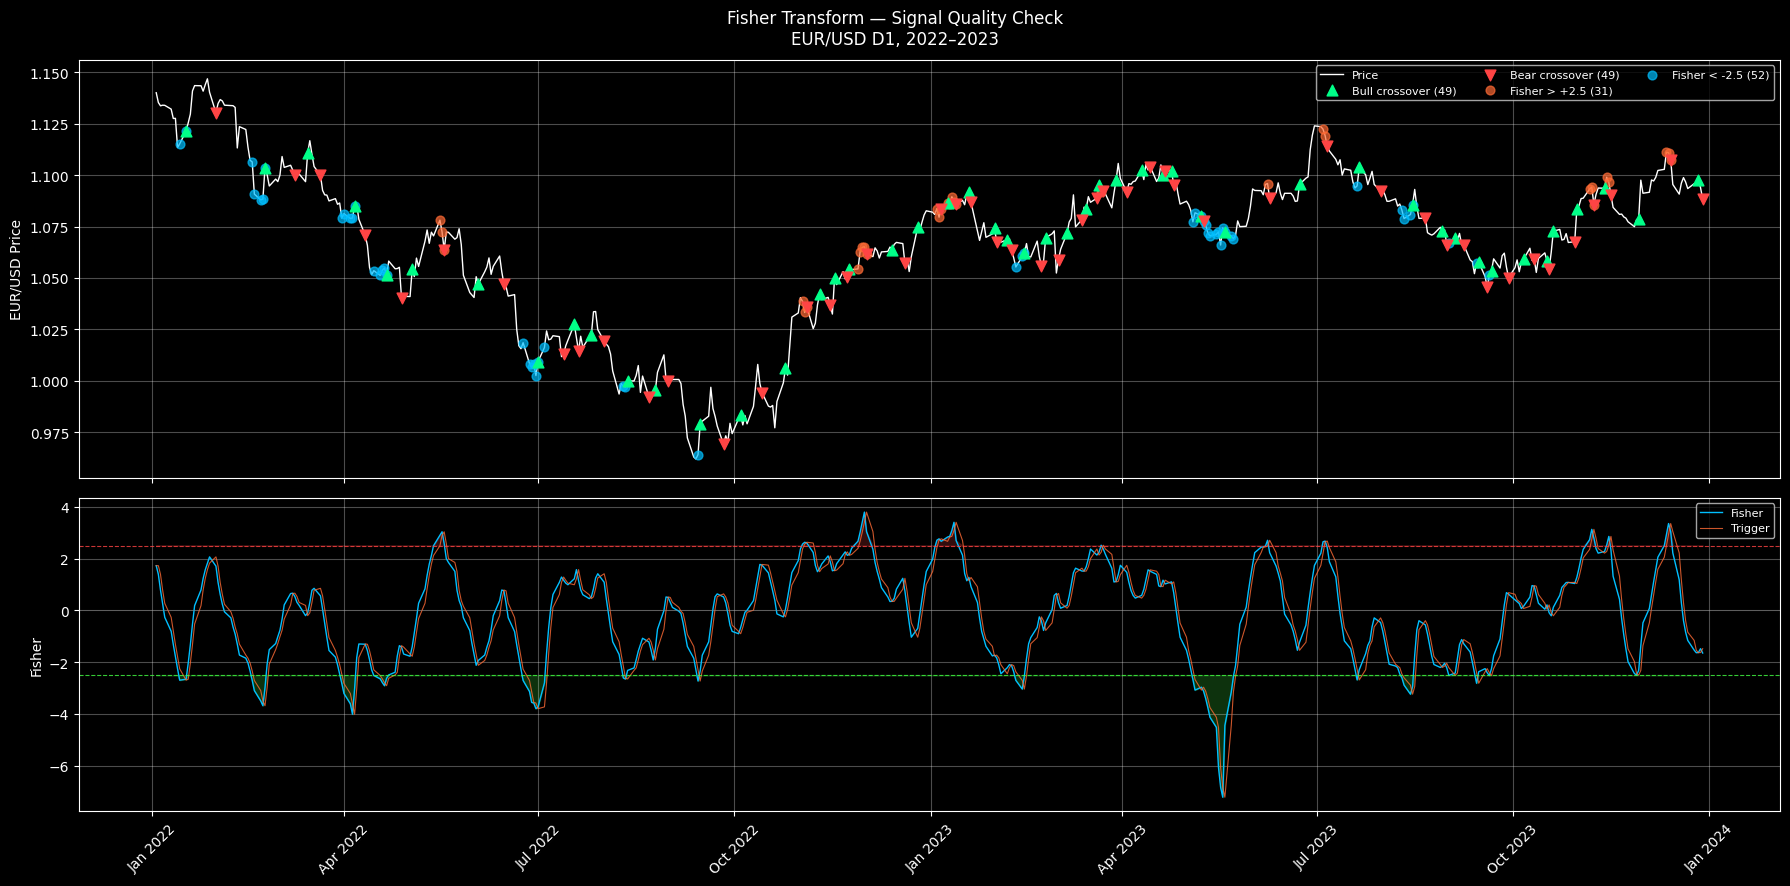

Bull signals: 49, Bear signals: 49
Fisher > +2.5: 31 bars,  Fisher < -2.5: 52 bars


In [3]:
# ============================================================
# Cell 3 — Zoomed view: Fisher signals vs price turning points
# Focus: 2022-2023 (EUR/USD crash to parity + recovery)
# ============================================================

mask = (df.index >= '2022-01-01') & (df.index <= '2023-12-31')
z = df[mask].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 9), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1.5]})
fig.suptitle('Fisher Transform — Signal Quality Check\nEUR/USD D1, 2022–2023', fontsize=12)

# --- Price with crossover signals ---
ax1.plot(z.index, z['close'], color='white', linewidth=1.0, label='Price')

# Bullish crossover: Fisher crosses above Trigger
bull = z[(z['fisher'] > z['fisher_trig']) & 
         (z['fisher'].shift(1) <= z['fisher_trig'].shift(1))]
# Bearish crossover: Fisher crosses below Trigger
bear = z[(z['fisher'] < z['fisher_trig']) & 
         (z['fisher'].shift(1) >= z['fisher_trig'].shift(1))]

ax1.scatter(bull.index, bull['close'], marker='^', color='#00FF88', 
            s=60, zorder=5, label=f'Bull crossover ({len(bull)})')
ax1.scatter(bear.index, bear['close'], marker='v', color='#FF4444', 
            s=60, zorder=5, label=f'Bear crossover ({len(bear)})')

# Mark Fisher extremes on price (|Fisher| > 2.5)
ext_pos = z[z['fisher'] >  2.5]
ext_neg = z[z['fisher'] < -2.5]
ax1.scatter(ext_pos.index, ext_pos['close'], marker='o', color='#FF6B35', 
            s=40, zorder=4, alpha=0.7, label=f'Fisher > +2.5 ({len(ext_pos)})')
ax1.scatter(ext_neg.index, ext_neg['close'], marker='o', color='#00BFFF', 
            s=40, zorder=4, alpha=0.7, label=f'Fisher < -2.5 ({len(ext_neg)})')

ax1.set_ylabel('EUR/USD Price')
ax1.legend(loc='upper right', fontsize=8, ncol=3)

# --- Fisher with thresholds ---
ax2.plot(z.index, z['fisher'],      color='#00BFFF', linewidth=1.0, label='Fisher')
ax2.plot(z.index, z['fisher_trig'], color='#FF6B35', linewidth=0.8, 
         alpha=0.8, label='Trigger')
ax2.axhline( 2.5, color='#FF4444', linewidth=0.8, linestyle='--', alpha=0.8)
ax2.axhline(-2.5, color='#44FF44', linewidth=0.8, linestyle='--', alpha=0.8)
ax2.axhline(0,    color='gray',    linewidth=0.5, alpha=0.5)
ax2.fill_between(z.index, 2.5,  z['fisher'].clip(lower=2.5),  
                 alpha=0.2, color='#FF4444')
ax2.fill_between(z.index, -2.5, z['fisher'].clip(upper=-2.5), 
                 alpha=0.2, color='#44FF44')
ax2.set_ylabel('Fisher')
ax2.legend(loc='upper right', fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('Week10_Fisher_Signals_2022.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Bull signals: {len(bull)}, Bear signals: {len(bear)}")
print(f"Fisher > +2.5: {len(ext_pos)} bars,  Fisher < -2.5: {len(ext_neg)} bars")

In [4]:
# ============================================================
# Cell 4 — C1 Candidate Comparison: Fisher vs CyberCycle
# Signal statistics over full 10-year period
# ============================================================

# Fisher stats (already computed)
fisher_bull = ((df['fisher'] > df['fisher_trig']) & 
               (df['fisher'].shift(1) <= df['fisher_trig'].shift(1))).sum()
fisher_bear = ((df['fisher'] < df['fisher_trig']) & 
               (df['fisher'].shift(1) >= df['fisher_trig'].shift(1))).sum()
fisher_total = fisher_bull + fisher_bear

# COG stats
cog_bull = ((df['cog'] > df['cog_trig']) & 
            (df['cog'].shift(1) <= df['cog_trig'].shift(1))).sum()
cog_bear = ((df['cog'] < df['cog_trig']) & 
            (df['cog'].shift(1) >= df['cog_trig'].shift(1))).sum()
cog_total = cog_bull + cog_bear

# Fisher extreme readings
fisher_ext = (df['fisher'].abs() > 2.5).sum()
fisher_ext_pct = fisher_ext / len(df) * 100

print("=" * 55)
print("  C1 CANDIDATE COMPARISON — EUR/USD D1 (2596 bars)")
print("=" * 55)
print(f"\n{'Metric':<35} {'Fisher':>8} {'COG':>8}")
print("-" * 55)
print(f"{'Total crossover signals':<35} {fisher_total:>8} {cog_total:>8}")
print(f"{'Bull signals':<35} {fisher_bull:>8} {cog_bull:>8}")
print(f"{'Bear signals':<35} {fisher_bear:>8} {cog_bear:>8}")
print(f"{'Avg bars per signal':<35} {len(df)/fisher_total:>8.1f} {len(df)/cog_total:>8.1f}")
print(f"{'|Value| > threshold bars (%)':<35} {fisher_ext_pct:>7.1f}% {'N/A':>8}")
print(f"{'Output range':<35} {'±7.4':>8} {'-5.56 to -5.44':>8}")
print(f"{'Statistical thresholds':<35} {'±2.5':>8} {'None':>8}")
print(f"{'Needs preprocessor':<35} {'No':>8} {'No':>8}")
print(f"{'Zero lag':<35} {'No':>8} {'Yes':>8}")
print("-" * 55)
print("\nCyberCycle (Week 8, from memory):")
print(f"  Total signals (EUR/USD D1):  ~380 | Avg: ~6.8 bars/signal")
print(f"  Requires RoofingFilter preprocessor: YES")
print(f"  Trend gate required (FAMA):          YES")
print("\nBaseline for comparison — FAMA crossovers: 252 (10.3 bars/signal)")
print("=" * 55)

  C1 CANDIDATE COMPARISON — EUR/USD D1 (2596 bars)

Metric                                Fisher      COG
-------------------------------------------------------
Total crossover signals                  484      522
Bull signals                             242      261
Bear signals                             242      261
Avg bars per signal                      5.4      5.0
|Value| > threshold bars (%)           16.0%      N/A
Output range                            ±7.4 -5.56 to -5.44
Statistical thresholds                  ±2.5     None
Needs preprocessor                        No       No
Zero lag                                  No      Yes
-------------------------------------------------------

CyberCycle (Week 8, from memory):
  Total signals (EUR/USD D1):  ~380 | Avg: ~6.8 bars/signal
  Requires RoofingFilter preprocessor: YES
  Trend gate required (FAMA):          YES

Baseline for comparison — FAMA crossovers: 252 (10.3 bars/signal)


Merged bars: 2591 (lost 5 warmup bars)

  FAMA FILTER EFFECT ON FISHER SIGNALS

Metric                                  Raw  Filtered
----------------------------------------------------
Bull signals                            242       122
Bear signals                            242       134
Total signals                           484       256
Avg bars per signal                     5.4      10.1
Signal reduction                          —     47.1%
----------------------------------------------------

FAMA Baseline signals (for reference): 252 (10.3 bars/signal)


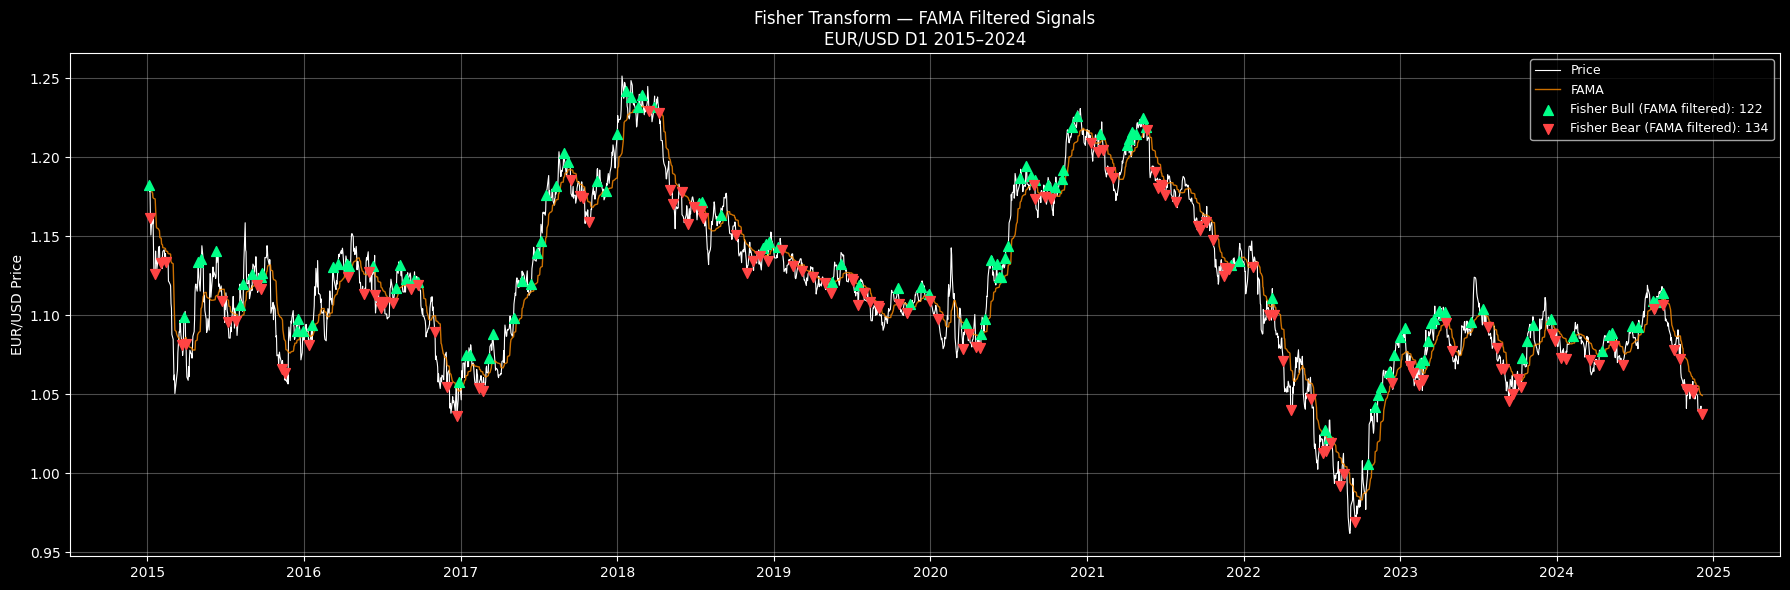

In [5]:
# ============================================================
# Cell 5 — BONUS: Fisher filtered by FAMA Baseline
# ============================================================

# Load MAMA/FAMA data
mama_df = pd.read_csv('C:/zorro/Data/MAMA_EURUSD_D1.csv',
                      header=None, names=['bar','close','mama','fama'])

# Merge on bar number
merged = df.merge(mama_df[['bar','fama']], on='bar', how='inner')
print(f"Merged bars: {len(merged)} (lost {len(df)-len(merged)} warmup bars)")

# Restore correct date index immediately after merge
merged.index = pd.bdate_range(start='2015-01-02', periods=len(merged))

# FAMA direction filter
merged['fama_bull'] = merged['close'] > merged['fama']
merged['fama_bear'] = merged['close'] < merged['fama']

# Raw Fisher crossovers
raw_bull = (merged['fisher'] > merged['fisher_trig']) & \
           (merged['fisher'].shift(1) <= merged['fisher_trig'].shift(1))
raw_bear = (merged['fisher'] < merged['fisher_trig']) & \
           (merged['fisher'].shift(1) >= merged['fisher_trig'].shift(1))

# FAMA-filtered crossovers
filt_bull = raw_bull & merged['fama_bull']
filt_bear = raw_bear & merged['fama_bear']

# Stats
print("\n" + "=" * 52)
print("  FAMA FILTER EFFECT ON FISHER SIGNALS")
print("=" * 52)
print(f"\n{'Metric':<35} {'Raw':>7} {'Filtered':>9}")
print("-" * 52)
print(f"{'Bull signals':<35} {raw_bull.sum():>7} {filt_bull.sum():>9}")
print(f"{'Bear signals':<35} {raw_bear.sum():>7} {filt_bear.sum():>9}")
print(f"{'Total signals':<35} {raw_bull.sum()+raw_bear.sum():>7} {filt_bull.sum()+filt_bear.sum():>9}")
print(f"{'Avg bars per signal':<35} {len(merged)/(raw_bull.sum()+raw_bear.sum()):>7.1f} \
{len(merged)/(filt_bull.sum()+filt_bear.sum()):>9.1f}")
print(f"{'Signal reduction':<35} {'—':>7} \
{(1-(filt_bull.sum()+filt_bear.sum())/(raw_bull.sum()+raw_bear.sum()))*100:>8.1f}%")
print("-" * 52)
print(f"\nFAMA Baseline signals (for reference): 252 (10.3 bars/signal)")

# Chart
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(merged.index, merged['close'], color='white', linewidth=0.8, label='Price')
ax.plot(merged.index, merged['fama'],  color='#FF8C00', linewidth=1.0,
        alpha=0.8, label='FAMA')
ax.scatter(merged.index[filt_bull], merged['close'][filt_bull],
           marker='^', color='#00FF88', s=50, zorder=5,
           label=f"Fisher Bull (FAMA filtered): {filt_bull.sum()}")
ax.scatter(merged.index[filt_bear], merged['close'][filt_bear],
           marker='v', color='#FF4444', s=50, zorder=5,
           label=f"Fisher Bear (FAMA filtered): {filt_bear.sum()}")
ax.set_title('Fisher Transform — FAMA Filtered Signals\nEUR/USD D1 2015–2024', fontsize=12)
ax.set_ylabel('EUR/USD Price')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('Week10_Fisher_FAMA_Filtered.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cell 6 — save marker
print("Week10_Fisher_IFT_COG_Analysis.ipynb — Day 4 EUR/USD D1 complete")
print("Day 5: BTC/USD H4 cross-asset validation")

Week10_Fisher_IFT_COG_Analysis.ipynb — Day 4 EUR/USD D1 complete
Day 5: BTC/USD H4 cross-asset validation


In [7]:
# ============================================================
# Cell 7 — BTC/USD H4 Cross-Asset Validation
# ============================================================

btc = pd.read_csv('C:/zorro/Data/Fisher_IFT_COG_BTCUSD_H4.csv')
dates_btc = pd.bdate_range(start='2018-01-02', periods=len(btc), freq='4h')
btc.index = dates_btc

print(f"BTC/USD H4: {len(btc)} bars")
print(f"Date range: {btc.index[0]} → {btc.index[-1]}")
print(f"Price range: ${btc['close'].min():,.0f} → ${btc['close'].max():,.0f}")

# Signal stats
btc_bull = ((btc['fisher'] > btc['fisher_trig']) & 
            (btc['fisher'].shift(1) <= btc['fisher_trig'].shift(1))).sum()
btc_bear = ((btc['fisher'] < btc['fisher_trig']) & 
            (btc['fisher'].shift(1) >= btc['fisher_trig'].shift(1))).sum()
btc_total = btc_bull + btc_bear

print("\n" + "=" * 58)
print("  CROSS-ASSET COMPARISON — same parameters, no retuning")
print("=" * 58)
print(f"\n{'Metric':<35} {'EUR/USD D1':>10} {'BTC/USD H4':>10}")
print("-" * 58)
print(f"{'Bars':<35} {len(df):>10} {len(btc):>10}")
print(f"{'Fisher mean':<35} {df['fisher'].mean():>10.3f} {btc['fisher'].mean():>10.3f}")
print(f"{'Fisher std':<35} {df['fisher'].std():>10.3f} {btc['fisher'].std():>10.3f}")
print(f"{'Fisher min/max':<35} {df['fisher'].min():.2f}/{df['fisher'].max():.2f} \
{btc['fisher'].min():.2f}/{btc['fisher'].max():.2f}")
print(f"{'EO min/max':<35} {df['elegant_osc'].min():.3f}/{df['elegant_osc'].max():.3f} \
{btc['elegant_osc'].min():.3f}/{btc['elegant_osc'].max():.3f}")
print(f"{'COG mean':<35} {df['cog'].mean():>10.4f} {btc['cog'].mean():>10.4f}")
print(f"{'COG std':<35} {df['cog'].std():>10.4f} {btc['cog'].std():>10.4f}")
print(f"{'Fisher crossovers':<35} {len(df)/(484):>10.1f} {len(btc)/btc_total:>10.1f}")
print(f"{'  (bars per signal)':<35} {484:>10} {btc_total:>10}")
print("-" * 58)
print(f"\n  EO within ±1 (EUR/USD): {(df['elegant_osc'].abs()<1).all()}")
print(f"  EO within ±1 (BTC/USD): {(btc['elegant_osc'].abs()<1).all()}")
print(f"  COG near -5.5 (EUR):    {abs(df['cog'].mean() - (-5.5)) < 0.01}")
print(f"  COG near -5.5 (BTC):    {abs(btc['cog'].mean() - (-5.5)) < 0.05}")

BTC/USD H4: 10423 bars
Date range: 2018-01-02 00:00:00 → 2022-10-05 00:00:00
Price range: $3,221 → $108,888

  CROSS-ASSET COMPARISON — same parameters, no retuning

Metric                              EUR/USD D1 BTC/USD H4
----------------------------------------------------------
Bars                                      2596      10423
Fisher mean                             -0.132      0.156
Fisher std                               1.843      1.899
Fisher min/max                      -7.23/7.41 -7.26/7.59
EO min/max                          -0.823/0.703 -0.847/0.858
COG mean                               -5.5005    -5.4983
COG std                                 0.0137     0.0650
Fisher crossovers                          5.4        5.5
  (bars per signal)                        484       1882
----------------------------------------------------------

  EO within ±1 (EUR/USD): True
  EO within ±1 (BTC/USD): True
  COG near -5.5 (EUR):    True
  COG near -5.5 (BTC):    True


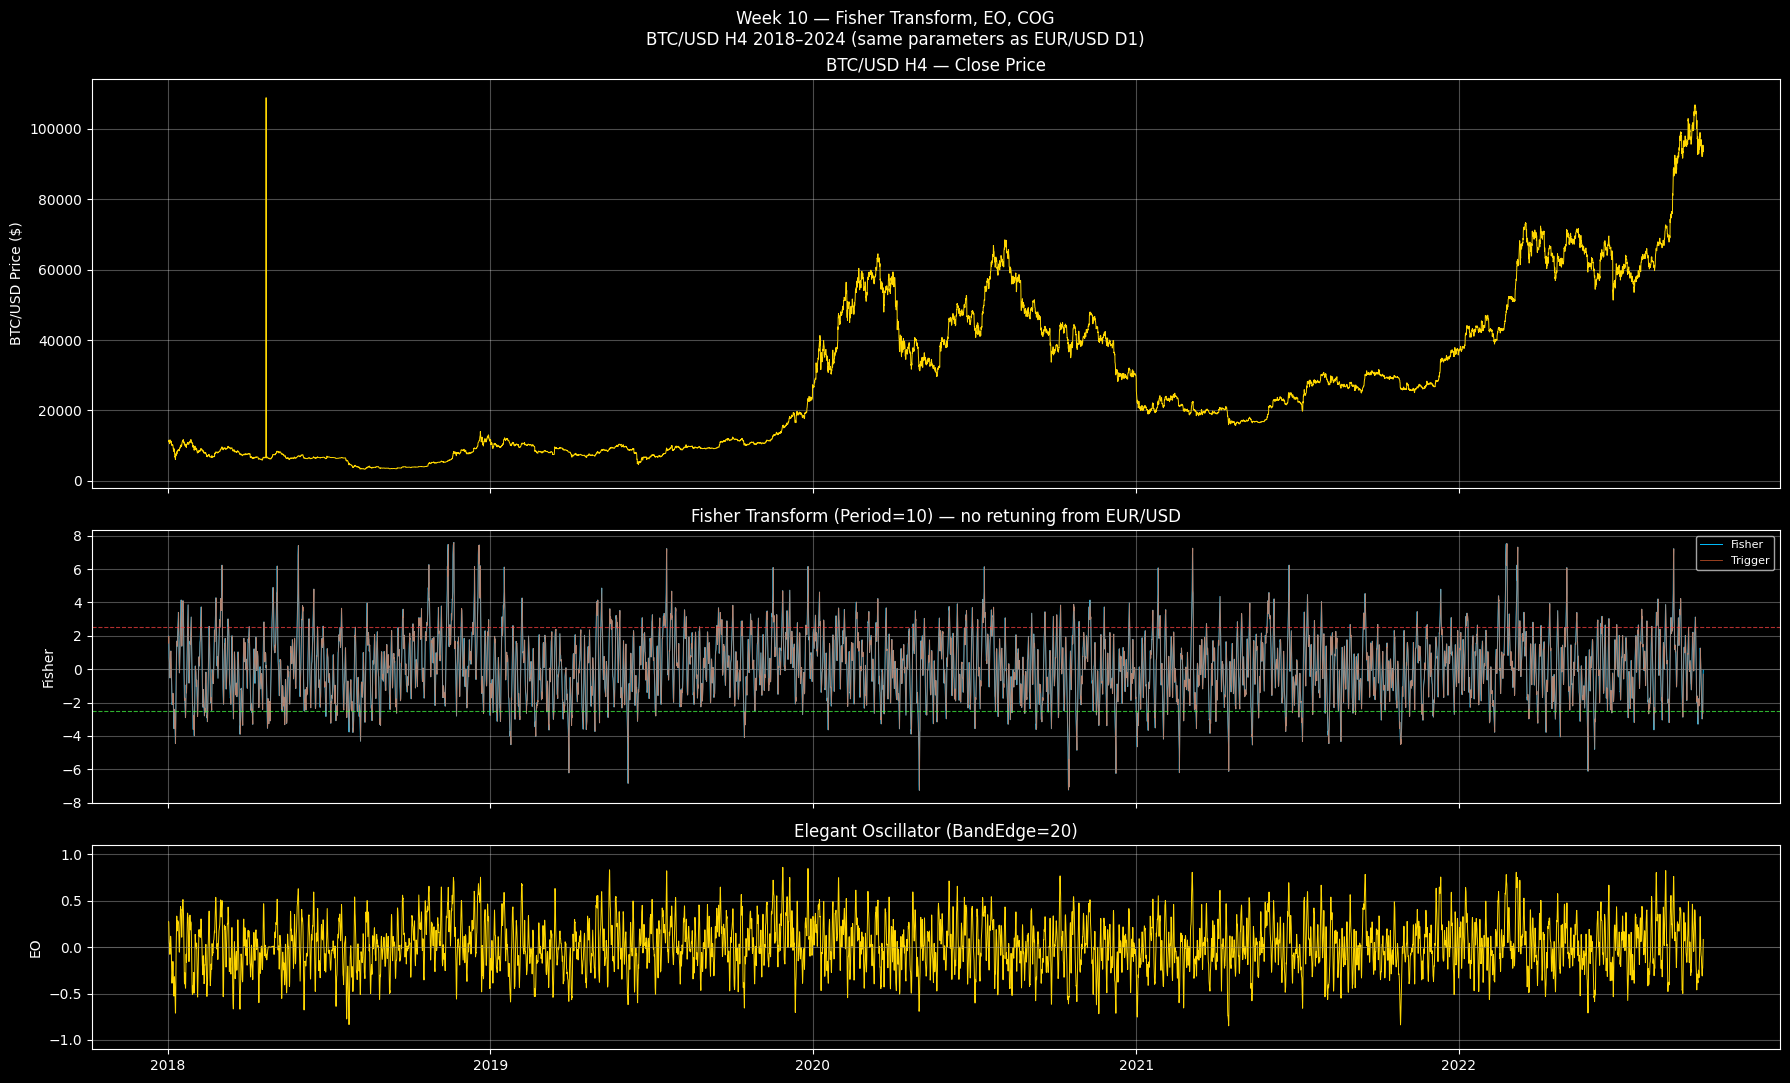

Day 5 BTC/USD H4 cross-asset validation complete.


In [8]:
# ============================================================
# Cell 8 — BTC/USD H4 Visual
# Note: using calendar 4h frequency (crypto trades 24/7)
# ============================================================

# Fix date index: calendar days, not business days
dates_btc_cal = pd.date_range(start='2018-01-02', periods=len(btc), freq='4h')
btc.index = dates_btc_cal

fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2, 1.5]})
fig.suptitle('Week 10 — Fisher Transform, EO, COG\nBTC/USD H4 2018–2024 (same parameters as EUR/USD D1)', 
             fontsize=12)

# Price
axes[0].plot(btc.index, btc['close'], color='#FFD700', linewidth=0.7)
axes[0].set_ylabel('BTC/USD Price ($)')
axes[0].set_title('BTC/USD H4 — Close Price')

# Fisher
axes[1].plot(btc.index, btc['fisher'],      color='#00BFFF', linewidth=0.7, label='Fisher')
axes[1].plot(btc.index, btc['fisher_trig'], color='#FF6B35', linewidth=0.6, 
             alpha=0.7, label='Trigger')
axes[1].axhline( 2.5, color='#FF4444', linewidth=0.8, linestyle='--', alpha=0.7)
axes[1].axhline(-2.5, color='#44FF44', linewidth=0.8, linestyle='--', alpha=0.7)
axes[1].axhline(0,    color='gray',    linewidth=0.5, alpha=0.5)
axes[1].set_ylabel('Fisher')
axes[1].set_title('Fisher Transform (Period=10) — no retuning from EUR/USD')
axes[1].legend(loc='upper right', fontsize=8)

# EO
axes[2].plot(btc.index, btc['elegant_osc'], color='#FFD700', linewidth=0.7)
axes[2].axhline(0, color='gray', linewidth=0.5, alpha=0.5)
axes[2].set_ylim(-1.1, 1.1)
axes[2].set_ylabel('EO')
axes[2].set_title('Elegant Oscillator (BandEdge=20)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('Week10_BTC_H4_Visual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Day 5 BTC/USD H4 cross-asset validation complete.")